In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score


In [2]:
split = "train"
filepath = f'split/p8_{split}.tsv'

if os.path.exists(filepath):
    df = pd.read_csv(filepath, sep='\t', encoding='latin-1')
else:
    # 파일이 없으면 다운로드 (in Colab)
    print('Downloading data from GitHub...')
    url = f"https://github.com/ssuai/asap/raw/refs/heads/main/{filepath}"
    df = pd.read_csv(url, sep='\t', encoding='latin-1')

df.head()


,essay_id,essay_set,essay,rater1_domain1,rater2_domain1,rater3_domain1,domain1_score,rater1_domain2,rater2_domain2,domain2_score,...,rater2_trait3,rater2_trait4,rater2_trait5,rater2_trait6,rater3_trait1,rater3_trait2,rater3_trait3,rater3_trait4,rater3_trait5,rater3_trait6
0,20716,8,A long time ago when I was in third grade I h...,18,16,NaN,34,NaN,NaN,NaN,...,4,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN
1,20717,8,Softball has to be one of the single most gre...,21,26,46.0,46,NaN,NaN,NaN,...,6,6,5,5,5.0,5.0,5.0,5.0,5.0,4.0
2,20718,8,"Some people like making people laugh, I love ...",15,20,40.0,40,NaN,NaN,NaN,...,5,4,4,4,4.0,4.0,4.0,4.0,4.0,4.0
3,20721,8,Well ima tell a story about the time i got @CA...,11,15,NaN,26,NaN,NaN,NaN,...,3,3,3,3,NaN,NaN,NaN,NaN,NaN,NaN
4,20722,8,@CAPS3 I'm going to tell @CAPS18 a little stor...,20,18,40.0,40,NaN,NaN,NaN,...,5,4,4,3,4.0,4.0,4.0,4.0,4.0,4.0


## Composite score 정의

Essay Set #8의 `domain1` 점수는 6개 trait 중 **Ideas, Organization, Sentence Fluency, Conventions**만 사용해 만든 composite입니다 (Voice·Word Choice 제외, Conventions는 가중치 2).

| 컬럼 | 의미 | 척도 |
| --- | --- | --- |
| `rater1_domain1` / `rater2_domain1` | 각 평가자의 composite | **0–30** |
| `rater3_domain1` | resolution 평가자 composite | **0–60** |
| `domain1_score` | resolved score | **0–60** |

공식 (루브릭):

- Rater 1·2 (각 평가자): `I + O + S + 2·C` → 0–30
- Rater 3: `2·(I + O + S + 2·C)` → 0–60
- Resolved: Rater 3가 없으면 `R1 + R2`, 있으면 `R3`

일치도 분석에서는 **같은 0–60 척도**로 맞춘 변환 점수를 사용합니다.

- `r1_60 = 2 × rater1_domain1`
- `r2_60 = 2 × rater2_domain1`
- `r3_60 = rater3_domain1`


In [3]:
# Composite 공식 검증 + 0–60 척도 변환
def rater_comp_30(frame, r):
    return (
        frame[f'rater{r}_trait1']
        + frame[f'rater{r}_trait2']
        + frame[f'rater{r}_trait5']
        + 2 * frame[f'rater{r}_trait6']
    )

df = df.copy()
df['r1_comp_check'] = rater_comp_30(df, 1)
df['r2_comp_check'] = rater_comp_30(df, 2)
df['r3_comp_check'] = 2 * rater_comp_30(df, 3)

print('R1 composite match:', (df['r1_comp_check'] == df['rater1_domain1']).mean())
print('R2 composite match:', (df['r2_comp_check'] == df['rater2_domain1']).mean())
mask3 = df['rater3_domain1'].notna()
print('R3 composite match:', (df.loc[mask3, 'r3_comp_check'] == df.loc[mask3, 'rater3_domain1']).mean())

resolved_pred = np.where(mask3, df['rater3_domain1'], df['rater1_domain1'] + df['rater2_domain1'])
print('Resolved score match:', (resolved_pred == df['domain1_score']).mean())

# 분석용 변환 점수 (0–60)
df['r1_60'] = 2 * df['rater1_domain1']
df['r2_60'] = 2 * df['rater2_domain1']
df['r3_60'] = df['rater3_domain1']

score_cols = ['rater1_domain1', 'rater2_domain1', 'rater3_domain1', 'domain1_score']
score_cols_60 = ['r1_60', 'r2_60', 'r3_60', 'domain1_score']

print(f"\nN essays: {len(df)}")
print(f"N with Rater 3: {mask3.sum()}")
print('\nMissing counts:')
display(df[score_cols].isna().sum().to_frame('n_missing'))


R1 composite match: 1.0
R2 composite match: 1.0
R3 composite match: 1.0
Resolved score match: 1.0

N essays: 434
N with Rater 3: 78

Missing counts:


,n_missing
rater1_domain1,0
rater2_domain1,0
rater3_domain1,356
domain1_score,0


### 기술통계 및 분포

원척도(R1·R2: 0–30, R3·resolved: 0–60)와 변환 척도(모두 0–60)를 함께 봅니다.


In [4]:
print('=== Original scale ===')
display(df[score_cols].describe())

print('=== Converted to 0–60 ===')
display(df[score_cols_60].describe())


=== Original scale ===


,rater1_domain1,rater2_domain1,rater3_domain1,domain1_score
count,434.000000,434.000000,78.000000,434.000000
mean,18.260369,18.582949,37.846154,36.937788
std,3.131299,3.172309,5.094119,5.738594
min,10.000000,5.000000,20.000000,15.000000
25%,16.000000,16.000000,36.000000,33.000000
50%,19.000000,19.000000,40.000000,37.000000
75%,20.000000,20.000000,40.000000,40.000000
max,30.000000,30.000000,50.000000,60.000000


=== Converted to 0–60 ===


,r1_60,r2_60,r3_60,domain1_score
count,434.000000,434.000000,78.000000,434.000000
mean,36.520737,37.165899,37.846154,36.937788
std,6.262597,6.344617,5.094119,5.738594
min,20.000000,10.000000,20.000000,15.000000
25%,32.000000,32.000000,36.000000,33.000000
50%,38.000000,38.000000,40.000000,37.000000
75%,40.000000,40.000000,40.000000,40.000000
max,60.000000,60.000000,50.000000,60.000000


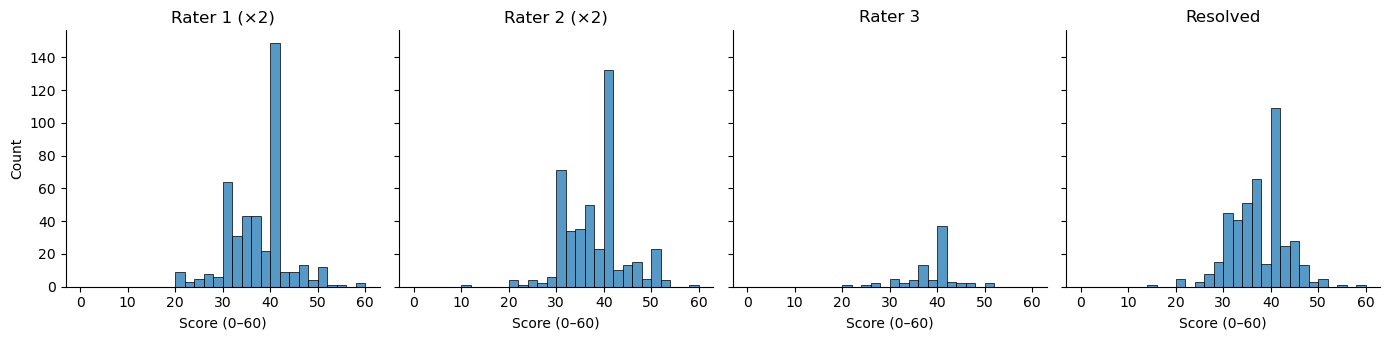

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
labels = [
    ('r1_60', 'Rater 1 (×2)'),
    ('r2_60', 'Rater 2 (×2)'),
    ('r3_60', 'Rater 3'),
    ('domain1_score', 'Resolved'),
]
for ax, (col, title) in zip(axes, labels):
    sns.histplot(df[col].dropna(), bins=np.arange(0, 62, 2), ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Score (0–60)')
    ax.set_ylabel('Count' if ax is axes[0] else '')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


### Pearson 상관

기본 채점은 Rater 1·2이므로 전체 essay에서 변환 점수(`r1_60`, `r2_60`) 상관을 보고, Rater 3가 있는 하위표본에서는 R1–R3, R2–R3도 함께 봅니다.


,pair,pearson_r,n
0,R1 vs R2,0.6140,434
1,R1 vs R3,0.7073,78
2,R2 vs R3,0.6264,78



Correlation matrix (pairwise, 0–60 scale):


,r1_60,r2_60,r3_60
r1_60,1.0000,0.6140,0.7073
r2_60,0.6140,1.0000,0.6264
r3_60,0.7073,0.6264,1.0000


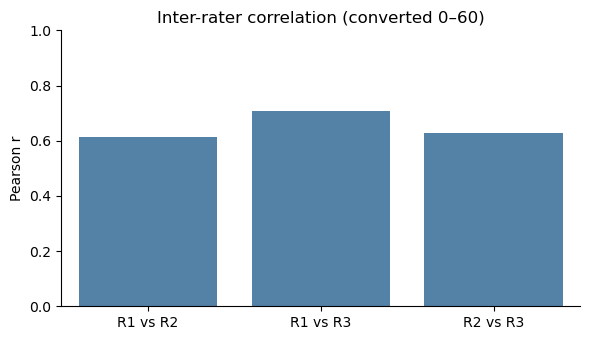

In [6]:
pair12 = df[['r1_60', 'r2_60']].dropna()
pair13 = df[['r1_60', 'r3_60']].dropna()
pair23 = df[['r2_60', 'r3_60']].dropna()

corr_df = pd.DataFrame([{
    'pair': 'R1 vs R2',
    'pearson_r': pair12['r1_60'].corr(pair12['r2_60']),
    'n': len(pair12),
}, {
    'pair': 'R1 vs R3',
    'pearson_r': pair13['r1_60'].corr(pair13['r3_60']) if len(pair13) else np.nan,
    'n': len(pair13),
}, {
    'pair': 'R2 vs R3',
    'pearson_r': pair23['r2_60'].corr(pair23['r3_60']) if len(pair23) else np.nan,
    'n': len(pair23),
}])
display(corr_df.round(4))

print('\nCorrelation matrix (pairwise, 0–60 scale):')
display(df[['r1_60', 'r2_60', 'r3_60']].corr(method='pearson').round(4))

plt.figure(figsize=(6, 3.5))
sns.barplot(data=corr_df, x='pair', y='pearson_r', color='steelblue')
plt.ylabel('Pearson r')
plt.xlabel('')
plt.ylim(0, 1)
plt.title('Inter-rater correlation (converted 0–60)')
sns.despine()
plt.tight_layout()
plt.show()


### Exact / near agreement (Rater 1 vs Rater 2)

Composite는 0–30 원척도(또는 0–60 변환)의 정수 점수입니다. trait처럼 “adjacent = 1점”이 adjudication rule과 1:1로 대응하진 않지만, 차이 분포를 보기 위해

- **Exact**: `|R1 − R2| = 0` (원척도 0–30)
- **|diff| ≤ 1, ≤ 2, ≤ 3**

비율을 확인합니다.


,n,exact_%,within_1_%,within_2_%,within_3_%,mean_|diff|,median_|diff|
0,434,26.27,46.77,63.13,77.19,2.06,2.0


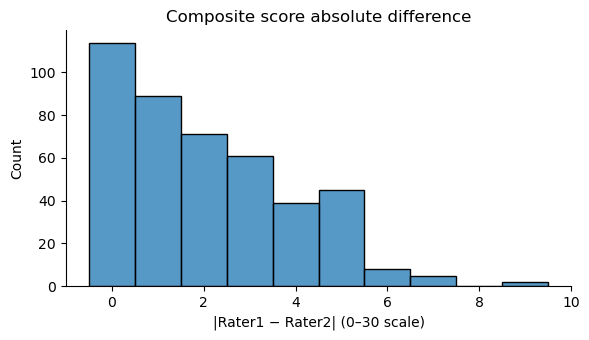

In [7]:
pair = df[['rater1_domain1', 'rater2_domain1']].dropna()
diff = (pair['rater1_domain1'] - pair['rater2_domain1']).abs()

agree_df = pd.DataFrame([{
    'n': len(pair),
    'exact_%': 100 * (diff == 0).mean(),
    'within_1_%': 100 * (diff <= 1).mean(),
    'within_2_%': 100 * (diff <= 2).mean(),
    'within_3_%': 100 * (diff <= 3).mean(),
    'mean_|diff|': diff.mean(),
    'median_|diff|': diff.median(),
}])
display(agree_df.round(2))

plt.figure(figsize=(6, 3.5))
sns.histplot(diff, bins=np.arange(-0.5, diff.max() + 1.5, 1), discrete=True)
plt.xlabel('|Rater1 − Rater2| (0–30 scale)')
plt.ylabel('Count')
plt.title('Composite score absolute difference')
sns.despine()
plt.tight_layout()
plt.show()


### Quadratic Weighted Kappa (QWK)

순서형 점수 일치도의 표준 지표입니다. **변환된 0–60 척도**에서 계산합니다 (선형 변환이므로 R1·R2의 QWK는 원척도 0–30과 동일).


,pair,QWK,n
0,R1 vs R2,0.6055,434
1,R1 vs R3,0.6726,78
2,R2 vs R3,0.6281,78


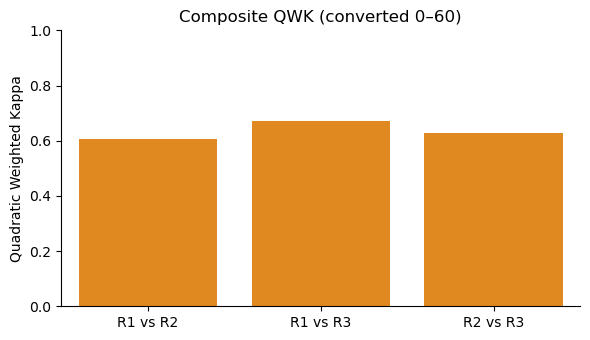

In [8]:
qwk_rows = [{
    'pair': 'R1 vs R2',
    'QWK': cohen_kappa_score(pair12['r1_60'], pair12['r2_60'], weights='quadratic'),
    'n': len(pair12),
}]
if len(pair13):
    qwk_rows.append({
        'pair': 'R1 vs R3',
        'QWK': cohen_kappa_score(pair13['r1_60'], pair13['r3_60'], weights='quadratic'),
        'n': len(pair13),
    })
if len(pair23):
    qwk_rows.append({
        'pair': 'R2 vs R3',
        'QWK': cohen_kappa_score(pair23['r2_60'], pair23['r3_60'], weights='quadratic'),
        'n': len(pair23),
    })

qwk_df = pd.DataFrame(qwk_rows)
display(qwk_df.round(4))

plt.figure(figsize=(6, 3.5))
sns.barplot(data=qwk_df, x='pair', y='QWK', color='darkorange')
plt.ylabel('Quadratic Weighted Kappa')
plt.xlabel('')
plt.ylim(0, 1)
plt.title('Composite QWK (converted 0–60)')
sns.despine()
plt.tight_layout()
plt.show()


### ICC (Rater 1·2)

`pingouin`으로 Two-way random, absolute agreement ICC를 계산합니다. Rater 3는 결측이 많으므로 **Rater 1·2**를 기준으로 합니다 (`ICC(A,1)` / `ICC(A,k)`, 구버전 `ICC2` / `ICC2k`).

원척도(0–30)와 변환 척도(0–60)는 선형 관계라 **ICC 값은 동일**합니다.

필요 시 아래 셀에서 pingouin을 설치하세요.


In [9]:
# %pip install pingouin --quiet


In [10]:
import pingouin as pg

def extract_icc(icc_table, single_aliases, average_aliases):
    """pingouin 버전별 Type 라벨 차이를 흡수 (구: ICC2/ICC2k, 신: ICC(A,1)/ICC(A,k))."""
    types = set(icc_table['Type'].astype(str))
    single = next((t for t in single_aliases if t in types), None)
    average = next((t for t in average_aliases if t in types), None)
    if single is None or average is None:
        raise KeyError(f'Expected ICC types not found. Available: {sorted(types)}')
    return (
        icc_table.loc[icc_table['Type'] == single, 'ICC'].iloc[0],
        icc_table.loc[icc_table['Type'] == average, 'ICC'].iloc[0],
        single,
        average,
    )

SINGLE_ALIASES = ['ICC(A,1)', 'ICC2']
AVERAGE_ALIASES = ['ICC(A,k)', 'ICC2k']

wide12 = df[['r1_60', 'r2_60']].dropna().rename(columns={'r1_60': 'rater1', 'r2_60': 'rater2'})
long12 = wide12.reset_index().melt(
    id_vars='index', var_name='rater', value_name='score'
).rename(columns={'index': 'essay_id'})

icc12 = pg.intraclass_corr(
    data=long12,
    targets='essay_id',
    raters='rater',
    ratings='score',
)
icc_single, icc_avg, single_label, avg_label = extract_icc(
    icc12, SINGLE_ALIASES, AVERAGE_ALIASES
)
print(f'Using labels: {single_label} / {avg_label}')

icc_df = pd.DataFrame([{
    'pair': 'R1 vs R2',
    'n': len(wide12),
    'ICC(A,1)': icc_single,
    'ICC(A,k)': icc_avg,
}])
display(icc_df.round(4))
display(icc12)


Using labels: ICC(A,1) / ICC(A,k)


,pair,n,"ICC(A,1)","ICC(A,k)"
0,R1 vs R2,434,0.6113,0.7588


,Type,ICC,F,df1,df2,pval,CI95
0,"ICC(1,1)",0.610494,4.134704,433,434,3.762010e-46,"[0.55, 0.67]"
1,"ICC(A,1)",0.611337,4.181277,433,433,1.001969e-46,"[0.55, 0.67]"
2,"ICC(C,1)",0.613995,4.181277,433,433,1.001969e-46,"[0.55, 0.67]"
3,"ICC(1,k)",0.758145,4.134704,433,434,3.762010e-46,"[0.71, 0.8]"
4,"ICC(A,k)",0.758794,4.181277,433,433,1.001969e-46,"[0.71, 0.8]"
5,"ICC(C,k)",0.760839,4.181277,433,433,1.001969e-46,"[0.71, 0.8]"


### (선택) Rater 3 포함 ICC

세 평가자가 모두 채점한 essay만으로, **변환된 0–60 척도**에서 ICC를 계산합니다.  
표본이 resolution 케이스에 편향되어 있고, R3는 adjudication용이므로 해석에 주의합니다.

이전 코드처럼 원척도(0–30)와 R3(0–60)를 섞으면 absolute-agreement ICC가 왜곡됩니다.


In [11]:
wide3 = df[['r1_60', 'r2_60', 'r3_60']].dropna().rename(
    columns={'r1_60': 'rater1', 'r2_60': 'rater2', 'r3_60': 'rater3'}
)
long3 = wide3.reset_index().melt(
    id_vars='index', var_name='rater', value_name='score'
).rename(columns={'index': 'essay_id'})

icc3 = pg.intraclass_corr(
    data=long3,
    targets='essay_id',
    raters='rater',
    ratings='score',
)
icc3_single, icc3_avg, _, _ = extract_icc(icc3, SINGLE_ALIASES, AVERAGE_ALIASES)

icc3_df = pd.DataFrame([{
    'pair': 'R1, R2, R3',
    'n': len(wide3),
    'ICC(A,1)': icc3_single,
    'ICC(A,k)': icc3_avg,
}])
print('Complete cases with all 3 raters (0–60 converted):')
display(icc3_df.round(4))


Complete cases with all 3 raters (0–60 converted):


,pair,n,"ICC(A,1)","ICC(A,k)"
0,"R1, R2, R3",78,0.4817,0.7361


### 결과 요약


In [12]:
summary = pd.DataFrame([{
    'metric': 'Pearson r (R1,R2)',
    'value': corr_df.loc[corr_df['pair'] == 'R1 vs R2', 'pearson_r'].iloc[0],
}, {
    'metric': 'Exact % (R1,R2, 0–30)',
    'value': agree_df['exact_%'].iloc[0],
}, {
    'metric': 'Within 2 % (R1,R2, 0–30)',
    'value': agree_df['within_2_%'].iloc[0],
}, {
    'metric': 'mean |diff| (R1,R2, 0–30)',
    'value': agree_df['mean_|diff|'].iloc[0],
}, {
    'metric': 'QWK (R1,R2)',
    'value': qwk_df.loc[qwk_df['pair'] == 'R1 vs R2', 'QWK'].iloc[0],
}, {
    'metric': 'ICC(A,1) (R1,R2)',
    'value': icc_df['ICC(A,1)'].iloc[0],
}, {
    'metric': 'ICC(A,k) (R1,R2)',
    'value': icc_df['ICC(A,k)'].iloc[0],
}])
display(summary.round(4))


,metric,value
0,"Pearson r (R1,R2)",0.6140
1,"Exact % (R1,R2, 0–30)",26.2673
2,"Within 2 % (R1,R2, 0–30)",63.1336
3,"mean |diff| (R1,R2, 0–30)",2.0645
4,"QWK (R1,R2)",0.6055
5,"ICC(A,1) (R1,R2)",0.6113
6,"ICC(A,k) (R1,R2)",0.7588


### 해석 가이드

- **척도 변환**: R1·R2 composite는 0–30, R3·resolved는 0–60입니다. R3를 포함한 상관·QWK·ICC는 반드시 `×2`로 맞춘 뒤 계산합니다.
- **QWK / ICC(A,1)**: 순서형·절대 일치도 지표. trait 분석과 같은 해석 기준을 쓰면 됩니다 (대략 0.4–0.6 moderate, 0.6–0.8 substantial).
- **ICC(A,k)**: 두 평가자 평균(또는 resolved에 가까운 집계)을 쓸 때의 신뢰도입니다.
- **Rater 3 포함 분석**: non-adjacency / cusp rule로 resolution이 필요한 어려운 케이스만 포함되므로, R1·R2 전체 표본보다 일치도가 낮게 나오는 것이 자연스럽습니다.
- Trait별 분석(`p8_traits.ipynb`)과 달리, 여기서는 Voice·Word Choice가 빠진 **가중 composite**에 대한 일치도입니다.
